In [1]:
import cv2
import json
import numpy as np
from tqdm import tqdm
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import torch

In [2]:
from typing import Dict

def get_rays_np(H, W, K, c2w):
    i, j = np.meshgrid(
        np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32), indexing="xy"
    )

    # 1. Calculate ray directions in the camera frame (Z-backward convention)
    # This part is correct for a Z-backward system: -np.ones_like(i)
    dirs = np.stack(
        [(i - K[0][2]) / K[0][0], -(j - K[1][2]) / K[1][1], -np.ones_like(i)], -1
    )

    # 2. *** FIX: Apply the COLMAP-to-NeRF axis flip to the c2w matrix ***
    # This converts the COLMAP-style c2w (Z-forward) to the NeRF-style c2w (Z-backward)
    # by flipping the Y and Z axes of the rotation matrix.
    c2w_flip = c2w.copy()
    # The standard NeRF flip is: c2w[:3, 1:3] *= -1
    # This is equivalent to multiplying the rotation matrix R by [[1, 0, 0], [0, -1, 0], [0, 0, -1]]
    c2w_flip[:3, 1:3] *= -1

    # 3. Rotate ray directions from camera frame to the world frame
    # Use the flipped c2w matrix for the rotation
    rays_d = np.sum(dirs[..., np.newaxis, :] * c2w_flip[:3, :3], -1)

    # 4. Translate camera frame's origin to the world frame.
    # Use the flipped c2w matrix for the translation
    rays_o = np.broadcast_to(c2w_flip[:3, -1], np.shape(rays_d))

    # 5. Reshape and normalize
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)
    rays_d = rays_d / np.linalg.norm(rays_d, axis=-1, keepdims=True)

    return rays_o, rays_d


def get_intrinsics(transform: Dict, downsample: int = 1) -> Dict:
    W = int(transform["w"])
    H = int(transform["h"])
    fx = float(transform["fl_x"])
    fy = float(transform.get("fl_y", fx))
    cx = float(transform.get("cx", W * 0.5))
    cy = float(transform.get("cy", H * 0.5))

    # downsample intrinsics
    W = W // downsample
    H = H // downsample
    fx = fx / downsample
    fy = fy / downsample
    cx = cx / downsample
    cy = cy / downsample
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])

    intrinsics = {
        "K": K,
        "W": W,
        "H": H,
        "fx": fx,
        "fy": fy,
        "cx": cx,
        "cy": cy,
    }
    return intrinsics


def resize_image(img: np.ndarray, H: int, W: int) -> np.ndarray:
    return cv2.resize(
        img,
        (W, H),
        interpolation=cv2.INTER_AREA,
    )


def resize_masks(mask: np.ndarray, H: int, W: int) -> np.ndarray:
    return cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)


def load_transforms(
    cfg: Dict, transform_json: str, downsample: int = 1, use_semantics: bool = True
):
    WORKSPACE = Path.cwd().parent.parent
    
    with open(transform_json, "r") as f:
        transforms = json.load(f)

    intrinsics = get_intrinsics(transforms, downsample)
    H, W = intrinsics["H"], intrinsics["W"]

    images, masks, poses = [], [], []

    for frame in tqdm(transforms["frames"], desc="Load Data"):
        image_path = WORKSPACE / frame["file_path"]
        img = np.array(Image.open(image_path))

        if use_semantics:
            stem = Path(image_path).stem
            mask_path = WORKSPACE / Path(cfg.paths.segmentation_mask) / f"{stem}_mask.png"
            mask = np.array(Image.open(mask_path))
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.float32)

        if downsample > 1:
            img = resize_image(img, H, W)
            if use_semantics:
                mask = resize_masks(mask, H, W)

        img = img.astype(np.float32) / 255.0
        images.append(img)

        if use_semantics:
            masks.append(mask)

        poses.append(np.array(frame["transform_matrix"], dtype=np.float32))

    images = np.stack(images)
    poses = np.stack(poses)
    masks = np.stack(masks) if use_semantics else None

    return images, masks, poses, intrinsics

In [3]:
def intersect_aabb(rays_o, rays_d, aabb_min=-1.0, aabb_max=1.0, eps=1e-6):
    """
    rays_o: (N, 3)
    rays_d: (N, 3)
    returns:
        t_near: (N,)
        t_far:  (N,)
        valid:  (N,) bool
    """

    inv_d = 1.0 / (rays_d + eps)

    t0 = (aabb_min - rays_o) * inv_d
    t1 = (aabb_max - rays_o) * inv_d

    t_min = np.minimum(t0, t1)
    t_max = np.maximum(t0, t1)

    t_near = np.max(t_min, axis=1)
    t_far  = np.min(t_max, axis=1)

    valid = t_far >= np.maximum(t_near, 0.0)

    return t_near, t_far, valid


In [4]:
WORKSPACE = Path.cwd().parent.parent
config_path = WORKSPACE / "cfg" /  "wheat_155160.yml"
cfg = OmegaConf.load(config_path)

downsample = cfg.data.downsample_factor
transform_json = WORKSPACE / cfg.files.transforms_json
mask_dir = WORKSPACE / cfg.paths.segmentation_mask
use_semantic_model = cfg.model.use_semantics

In [5]:
images, masks, poses, intrinsics = load_transforms(
    cfg, transform_json, downsample, use_semantics=use_semantic_model
)

print(images.shape)
print(masks.shape)
print(intrinsics.keys())

Load Data: 100%|██████████| 118/118 [00:31<00:00,  3.78it/s]


(118, 564, 1000, 3)
(118, 564, 1000)
dict_keys(['K', 'W', 'H', 'fx', 'fy', 'cx', 'cy'])


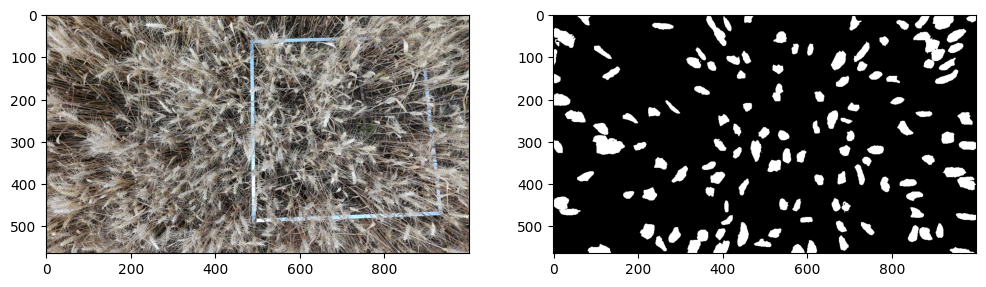

In [6]:
idx = np.random.randint(0, len(images))
img = images[idx]
mask = masks[idx]
fig, axs = plt.subplots(1, 2, figsize=(12, 10))
axs[0].imshow(img)
axs[1].imshow(mask, cmap="gray")
# plt.imsave("test_image.png", img)
# plt.imsave("test_mask.png", mask)
plt.show()

In [7]:
H = intrinsics["H"]
W = intrinsics["W"]
K = intrinsics["K"]

N = len(poses)
rays_o_list = []
rays_d_list = []
rgb_gt_list = []
mask_gt_list = []

for idx in tqdm(range(N), desc="Loading rays and rgb_gt", total=N):
    c2w = poses[idx]
    target_image = images[idx]
    rays_o, rays_d = get_rays_np(H, W, K, c2w)
    target_px_values = target_image.reshape(-1, 3)
    rays_o_list.append(rays_o)
    rays_d_list.append(rays_d)
    rgb_gt_list.append(target_px_values)

    if masks is not None:
        target_mask = masks[idx]
        target_mask_values = target_mask.reshape(-1, 1)
        mask_gt_list.append(target_mask_values)

rays_o_list = np.array(rays_o_list).reshape(-1, 3)
rays_d_list = np.array(rays_d_list).reshape(-1, 3)
rgb_gt_list = np.array(rgb_gt_list).reshape(-1, 3)
print(f"rays_o_all: {rays_o_list.shape}")
print(f"rays_d_list: {rays_d_list.shape}")
print(f"rgb_gt_list: {rgb_gt_list.shape}")

if masks is not None:
    mask_gt_list = np.array(mask_gt_list).reshape(-1, 1)
    print(f"mask_gt_list: {mask_gt_list.shape}")

Loading rays and rgb_gt: 100%|██████████| 118/118 [00:31<00:00,  3.71it/s]


rays_o_all: (66552000, 3)
rays_d_list: (66552000, 3)
rgb_gt_list: (66552000, 3)
mask_gt_list: (66552000, 1)


In [8]:
near, far, valid = intersect_aabb(rays_o_list, rays_d_list)
print("Valid rays:", valid.sum(), "/", len(valid))

Valid rays: 66552000 / 66552000


In [9]:
rays_o = rays_o_list[valid]
rays_d = rays_d_list[valid]
masks = mask_gt_list[valid]
rgbs = rgb_gt_list[valid]

near   = np.maximum(near[valid], 0.0)
far    = far[valid]

print(rays_o.shape)
print(rays_d.shape)
print(masks.shape)
print(near.shape)
print(far.shape)

(66552000, 3)
(66552000, 3)
(66552000, 1)
(66552000,)
(66552000,)


In [13]:
ray_path = WORKSPACE / cfg.paths.root / "rays.npz"

np.savez_compressed(
    ray_path,
    rays_o=rays_o.astype(np.float32),
    rays_d=rays_d.astype(np.float32),
    rgb_gt=rgbs.astype(np.float32),
    masks_gt=masks.astype(np.float32) if masks is not None else None,
    H=H,
    W=W,
    K=K.astype(np.float32),
    valid=valid,
    near=near,
    far=far,
)
print(f"Saved dataset to: {ray_path}")

Saved dataset to: c:\Users\Sesko\Dev\masterthesis\semantic_nerf\results\wheat_155160\rays.npz
